# Notebook 2 – Adult Income (Binary Classification)

## Overview
We benchmark six tabular-learning methods on the UCI Adult Income dataset:
**ResNet**, **FT-Transformer**, **XGBoost**, **LightGBM**, **Random Forest**,
and **Logistic Regression**.  
Each model is tuned with **Optuna** (20 trials) and evaluated across 3 seeds.  
Metrics: **Accuracy**, **AUC-ROC**, **F1**.


In [50]:
# !pip install pytorch-tabnet "rtdl==0.0.13" optuna xgboost lightgbm ucimlrepo scikit-learn pandas numpy matplotlib seaborn shap

## Imports

In [51]:
import warnings
warnings.filterwarnings("ignore")

import random
import time
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from rtdl_revisiting_models import ResNet, FTTransformer
from rtdl_revisiting_models import ResNet as _RTDLResNet
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import xgboost as xgb
import lightgbm as lgb

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from sklearn.model_selection import train_test_split

device_ = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device_}")

Using device: cpu


## Configuration
These parameters denote the key parameters for the experiments.
- SEEDS: Set 3 specific seed numbers
- N_OPTUNA_TRIALS: Number of trials to run for Optuna hyperparameter tuning
- TEST_SIZE: Proportion of data used for train-test split
- VAL_FRAC: Proportion of training data divided into train-validation (effectively 60/20/20 for train/val/test split)
- N_PATIENCE: Number of trials for early stopping when validation performance stops improving
- OPT_EPOCHS: Number of epochs to run for Optuna hyperparameter tuning
- FT_EPOCHS: Number of epochs to run when training across seeds

In [52]:
SEEDS           = [42, 123, 456]
N_OPTUNA_TRIALS = 20
TEST_SIZE       = 0.20
VAL_FRAC        = 0.25
N_PATIENCE      = 10
OPT_EPOCHS      = 50
TR_EPOCHS       = 100
N_BATCH_SIZE    = 1024

## Data Loading & EDA

- Load dataset and treat " ?" as missing values.
- Split into features (X_raw) and target (y_raw).
- Inspect shape, data types, and summary statistics for understanding the data.

In [53]:
df = pd.read_csv("adult.csv", na_values=" ?", skipinitialspace=True)

X_raw = df.drop(columns=["income"]).copy()
y_raw = df["income"].copy()

print("Features shape:", X_raw.shape)
print()
print(X_raw.dtypes)
print()
print(X_raw.describe())

Features shape: (32561, 14)

age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
dtype: object

                age        fnlwgt  education-num  capital-gain  capital-loss  \
count  32561.000000  3.256100e+04   32561.000000  32561.000000  32561.000000   
mean      38.581647  1.897784e+05      10.080679   1077.648844     87.303830   
std       13.640433  1.055500e+05       2.572720   7385.292085    402.960219   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783560e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.370510e+05      12.0000

- Clean target values by removing extra spaces.
- Check unique labels and their distribution to understand class balance.

In [54]:
target_series = y_raw.astype(str).str.strip()
print("Unique target values:", target_series.unique())
print(target_series.value_counts())

Unique target values: ['<=50K' '>50K']
income
<=50K    24720
>50K      7841
Name: count, dtype: int64


In [55]:
# Missing Values Check
print("Missing values after loading:")
missing_counts = X_raw.isna().sum()
print(missing_counts[missing_counts > 0])

Missing values after loading:
Series([], dtype: int64)


- Plot histograms for key numerical features.
- Helps visualise data distribution and detect skewness or outliers.

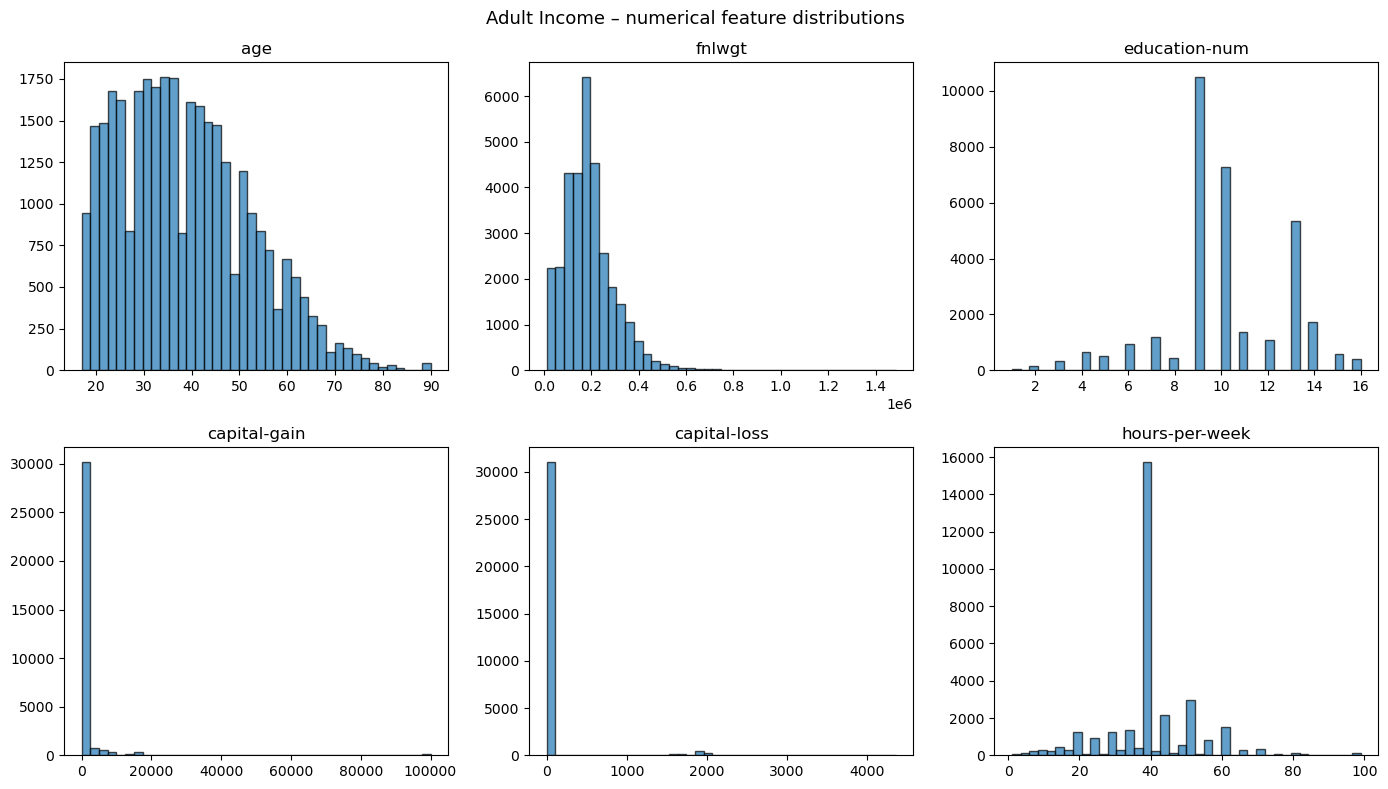

In [56]:
num_cols_eda = [
    'age', 'fnlwgt', 'education-num',
    'capital-gain', 'capital-loss', 'hours-per-week'
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), num_cols_eda):
    ax.hist(X_raw[col].dropna(), bins=40, edgecolor='k', alpha=0.7)
    ax.set_title(col)

plt.suptitle("Adult Income – numerical feature distributions", fontsize=13)
plt.tight_layout()
plt.show()

## Preprocessing

- Define numerical and categorical feature groups.
- Convert the target into binary labels (>50K = 1, otherwise 0).
- Handle missing values by using median imputation for numerical features and "Unknown" for categorical features.
- Create binary indicators for capital gain and capital loss, then apply log transformation to reduce skewness.
- Drop fnlwgt and check that no missing values remain.

In [57]:
# Raw columns
num_cols_raw = [
    'age', 'fnlwgt', 'education-num',
    'capital-gain', 'capital-loss', 'hours-per-week'
]

cat_cols = [
    'workclass', 'education', 'marital-status', 'occupation',
    'relationship', 'race', 'sex', 'native-country'
]

In [58]:
y_series = y_raw.astype(str).str.strip().str.replace('.', '', regex=False)
y = np.where(y_series == '>50K', 1, 0).astype(np.int64)

print(f"Positive rate: {y.mean():.3%}")
print(pd.Series(y).value_counts())

Positive rate: 24.081%
0    24720
1     7841
Name: count, dtype: int64


In [59]:
X_proc = X_raw.copy()

# Replace '?' with NaN in categorical columns
for col in cat_cols:
    X_proc[col] = X_proc[col].astype(str).str.strip().replace('?', np.nan)

# Impute numeric columns with median
for col in num_cols_raw:
    X_proc[col] = X_proc[col].fillna(X_proc[col].median())

# Impute categorical columns with 'Unknown'
for col in cat_cols:
    X_proc[col] = X_proc[col].fillna('Unknown')

# Binary flags before log transform
X_proc['has_capital_gain'] = (X_proc['capital-gain'] > 0).astype(int)
X_proc['has_capital_loss'] = (X_proc['capital-loss'] > 0).astype(int)

# Log transform skewed monetary features
X_proc['capital-gain'] = np.log1p(X_proc['capital-gain'])
X_proc['capital-loss'] = np.log1p(X_proc['capital-loss'])

# Drop survey-weight column
X_proc = X_proc.drop(columns=['fnlwgt'])

print("Missing after preprocessing:", X_proc.isnull().sum().sum())
print(X_proc.head())

Missing after preprocessing: 0
   age workclass     education  education-num marital-status  \
0   90   Unknown       HS-grad              9        Widowed   
1   82   Private       HS-grad              9        Widowed   
2   66   Unknown  Some-college             10        Widowed   
3   54   Private       7th-8th              4       Divorced   
4   41   Private  Some-college             10      Separated   

          occupation   relationship   race     sex  capital-gain  \
0            Unknown  Not-in-family  White  Female           0.0   
1    Exec-managerial  Not-in-family  White  Female           0.0   
2            Unknown      Unmarried  Black  Female           0.0   
3  Machine-op-inspct      Unmarried  White  Female           0.0   
4     Prof-specialty      Own-child  White  Female           0.0   

   capital-loss  hours-per-week native-country  has_capital_gain  \
0      8.379539              40  United-States                 0   
1      8.379539              18  United

In [60]:
# Define final column groups after preprocessing
num_cols_final = [
    'age', 'education-num', 'capital-gain',
    'capital-loss', 'hours-per-week',
    'has_capital_gain', 'has_capital_loss'
]

cat_cols_final = [
    'workclass', 'education', 'marital-status', 'occupation',
    'relationship', 'race', 'sex', 'native-country'
]

## Data Splitting (60 / 20 / 20)

- Split data into training and temporary sets using stratified sampling.
- Further split the temporary set into validation and test sets.
- Ensures consistent class distribution across all splits.

In [61]:
# First split: train vs temp (val + test)
X_train_df, X_temp_df, y_train, y_temp = train_test_split(
    X_proc, y,
    test_size=TEST_SIZE + (1 - TEST_SIZE) * VAL_FRAC,  
    random_state=42,
    stratify=y
)

# Second split: val vs test
X_val_df, X_test_df, y_val, y_test = train_test_split(
    X_temp_df, y_temp,
    test_size=TEST_SIZE / (TEST_SIZE + (1 - TEST_SIZE) * VAL_FRAC),  
    random_state=42,
    stratify=y_temp
)

Classical Model Pipeline
- Apply one-hot encoding to categorical features.
- Align validation and test columns with training data.
- Convert all features to float for consistency.
- Ensures compatibility across classical models.

In [62]:
# Classical models pipeline - logistic regression, random forest, xgboost, lightgbm

X_train_c = pd.get_dummies(X_train_df, drop_first=True)
X_val_c   = pd.get_dummies(X_val_df, drop_first=True)
X_test_c  = pd.get_dummies(X_test_df, drop_first=True)

# Align columns
X_val_c  = X_val_c.reindex(columns=X_train_c.columns, fill_value=0)
X_test_c = X_test_c.reindex(columns=X_train_c.columns, fill_value=0)

# Convert to float for consistency
X_train_c = X_train_c.astype(np.float32)
X_val_c   = X_val_c.astype(np.float32)
X_test_c  = X_test_c.astype(np.float32)

print("Classical shapes:")
print("Train:", X_train_c.shape)
print("Val:  ", X_val_c.shape)
print("Test: ", X_test_c.shape)

Classical shapes:
Train: (19536, 100)
Val:   (6512, 100)
Test:  (6513, 100)


Deep Learning Pipeline
- Encode categorical features using ordinal encoding and shift values for embedding compatibility.
- Standardise numerical features using StandardScaler.
- Convert data into NumPy arrays for model input.
- Prepare feature shapes and cardinalities for ResNet and FT-Transformer.

In [63]:
# Deep learning pipeline ResNet, FT-Transformer

ord_enc = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_train_cat = ord_enc.fit_transform(X_train_df[cat_cols_final]).astype(np.int64)
X_val_cat = ord_enc.transform(X_val_df[cat_cols_final]).astype(np.int64)
X_test_cat = ord_enc.transform(X_test_df[cat_cols_final]).astype(np.int64)

# Shift so unknown becomes 0
X_train_cat = X_train_cat + 1
X_val_cat = X_val_cat + 1
X_test_cat = X_test_cat + 1

cat_cardinalities = [len(categories) + 1 for categories in ord_enc.categories_]

scaler_num = StandardScaler()
X_train_num = scaler_num.fit_transform(X_train_df[num_cols_final].astype(np.float32)).astype(np.float32)
X_val_num = scaler_num.transform(X_val_df[num_cols_final].astype(np.float32)).astype(np.float32)
X_test_num = scaler_num.transform(X_test_df[num_cols_final].astype(np.float32)).astype(np.float32)

y_train_np = np.asarray(y_train).astype(np.int64)
y_val_np = np.asarray(y_val).astype(np.int64)
y_test_np = np.asarray(y_test).astype(np.int64)

print("Numeric shapes:")
print("Train:", X_train_num.shape)
print("Val:  ", X_val_num.shape)
print("Test: ", X_test_num.shape)

print("\nCategorical shapes:")
print("Train:", X_train_cat.shape)
print("Val:  ", X_val_cat.shape)
print("Test: ", X_test_cat.shape)

print("\nTarget shapes:")
print("Train:", y_train_np.shape)
print("Val:  ", y_val_np.shape)
print("Test: ", y_test_np.shape)

print("\nCategorical cardinalities:")
print(cat_cardinalities)

Numeric shapes:
Train: (19536, 7)
Val:   (6512, 7)
Test:  (6513, 7)

Categorical shapes:
Train: (19536, 8)
Val:   (6512, 8)
Test:  (6513, 8)

Target shapes:
Train: (19536,)
Val:   (6512,)
Test:  (6513,)

Categorical cardinalities:
[10, 17, 8, 16, 7, 6, 3, 42]


- Verify categorical values are non-negative and within expected ranges.
- Confirm correct data types for numerical, categorical, and target variables.
- Check target values to ensure proper binary encoding.

In [64]:
print("Min categorical value:", X_train_cat.min())
print("Max values by column:", X_train_cat.max(axis=0))
print("Any negative in cat?", (X_train_cat < 0).any())

print("Numeric dtype:", X_train_num.dtype)
print("Categorical dtype:", X_train_cat.dtype)
print("Target dtype:", y_train_np.dtype)
print("Target unique values:", np.unique(y_train_np))

Min categorical value: 1
Max values by column: [ 9 16  7 15  6  5  2 41]
Any negative in cat? False
Numeric dtype: float32
Categorical dtype: int64
Target dtype: int64
Target unique values: [0 1]


## Helper Functions

- Set random seeds for reproducibility across NumPy, PyTorch, and CUDA.
- Define classification metrics: accuracy, AUC, and F1-score.
- Implement generic training and prediction functions for deep learning models with numerical and categorical inputs, including early stopping and optional timing.

In [65]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Reproducibility
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def compute_classification_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return acc, auc, f1


def train_tabular_model(
    model,
    X_num_tr,
    X_cat_tr,
    y_tr,
    X_num_v,
    X_cat_v,
    y_v,
    n_epochs,
    lr=1e-3,
    n_patience=N_PATIENCE,
    batch_size=N_BATCH_SIZE,
    val_batch_size=N_BATCH_SIZE,
    device_="cpu",
    use_amp=True,
    use_class_weight=False,
    timer=None,
):
    model = model.to(device_)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)

    if use_class_weight:
        pos_weight = float((y_tr == 0).sum()) / float((y_tr == 1).sum())
        criterion = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([pos_weight], dtype=torch.float32, device=device_)
        )
    else:
        criterion = nn.BCEWithLogitsLoss()

    amp_on = use_amp and torch.cuda.is_available() and str(device_).startswith("cuda")
    scaler = torch.amp.GradScaler(device=str(device_), enabled=amp_on)

    # Keep tensors on CPU; move batches to device during training
    X_num_tr_t = torch.as_tensor(X_num_tr, dtype=torch.float32)
    X_cat_tr_t = torch.as_tensor(X_cat_tr, dtype=torch.long) if X_cat_tr is not None else None
    y_tr_t = torch.as_tensor(y_tr, dtype=torch.float32)

    X_num_v_t = torch.as_tensor(X_num_v, dtype=torch.float32)
    X_cat_v_t = torch.as_tensor(X_cat_v, dtype=torch.long) if X_cat_v is not None else None
    y_v_t = torch.as_tensor(y_v, dtype=torch.float32)

    train_losses = []
    val_losses = []
    best_val = float("inf")
    best_state = None
    pat_cnt = 0

    for epoch in range(n_epochs):
        model.train()
        n = len(X_num_tr_t)
        idx = torch.randperm(n)
        ep_loss = 0.0

        for i in range(0, n, batch_size):
            b = idx[i:i + batch_size]

            xn = X_num_tr_t[b].to(device_, non_blocking=True)
            xc = X_cat_tr_t[b].to(device_, non_blocking=True) if X_cat_tr_t is not None else None
            yb = y_tr_t[b].to(device_, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            if timer:
                timer.start("forward")
            with torch.amp.autocast(device_type="cuda", enabled=amp_on):
                out = model(xn, xc).squeeze(-1)
                loss = criterion(out, yb)
            if timer:
                timer.stop("forward")

            if timer:
                timer.start("backward")
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            if timer:
                timer.stop("backward")

            ep_loss += loss.item() * len(b)

        model.eval()
        val_loss_acc = 0.0
        n_v = len(X_num_v_t)

        with torch.no_grad():
            if timer:
                timer.start("validation")

            for j in range(0, n_v, val_batch_size):
                xn_v = X_num_v_t[j:j + val_batch_size].to(device_, non_blocking=True)
                xc_v = (
                    X_cat_v_t[j:j + val_batch_size].to(device_, non_blocking=True)
                    if X_cat_v_t is not None else None
                )
                yb_v = y_v_t[j:j + val_batch_size].to(device_, non_blocking=True)

                with torch.amp.autocast(device_type="cuda", enabled=amp_on):
                    vout = model(xn_v, xc_v).squeeze(-1)
                    val_loss_acc += criterion(vout, yb_v).item() * len(xn_v)

            if timer:
                timer.stop("validation")

        vloss = val_loss_acc / n_v
        train_losses.append(ep_loss / n)
        val_losses.append(vloss)

        if vloss < best_val:
            best_val = vloss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            pat_cnt = 0
        else:
            pat_cnt += 1
            if pat_cnt >= n_patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, train_losses, val_losses


def predict_tabular_model(
    model,
    X_num,
    X_cat,
    device_,
    batch_size=N_BATCH_SIZE,
    timer=None,
):
    model.eval()
    model = model.to(device_)

    X_num_t = torch.as_tensor(X_num, dtype=torch.float32)
    X_cat_t = torch.as_tensor(X_cat, dtype=torch.long) if X_cat is not None else None

    amp_on = torch.cuda.is_available() and str(device_).startswith("cuda")

    logits = []
    probs = []

    with torch.no_grad():
        for i in range(0, len(X_num_t), batch_size):
            xn = X_num_t[i:i + batch_size].to(device_, non_blocking=True)
            xc = (
                X_cat_t[i:i + batch_size].to(device_, non_blocking=True)
                if X_cat_t is not None else None
            )

            if timer:
                timer.start("inference")
            with torch.amp.autocast(device_type="cuda", enabled=amp_on):
                out = model(xn, xc).squeeze(-1)
            if timer:
                timer.stop("inference")

            pr = torch.sigmoid(out)
            logits.append(out.cpu().numpy())
            probs.append(pr.cpu().numpy())

    logits = np.concatenate(logits)
    probs = np.concatenate(probs)
    preds = (probs >= 0.5).astype(int)

    return logits, probs, preds


class PhaseTimer:
    def __init__(self):
        self._totals = {}
        self._counts = {}
        self._start = {}

    def start(self, phase):
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        self._start[phase] = time.perf_counter()

    def stop(self, phase):
        if phase not in self._start:
            return
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        elapsed = time.perf_counter() - self._start[phase]
        self._totals[phase] = self._totals.get(phase, 0.0) + elapsed
        self._counts[phase] = self._counts.get(phase, 0) + 1

    def get_total(self, phase):
        return self._totals.get(phase, 0.0)

    def reset(self):
        self._totals.clear()
        self._counts.clear()
        self._start.clear()

    def report(self, label=""):
        total = sum(self._totals.values())
        print(f"\n--- Bottleneck Report {label} ---")
        for k, v in sorted(self._totals.items(), key=lambda x: -x[1]):
            pct = 100 * v / total if total > 0 else 0.0
            avg = 1000 * v / self._counts[k]
            print(f"{k:<20} {v:.3f}s ({pct:.1f}%) avg {avg:.2f} ms")
        print(f"TOTAL: {total:.3f}s\n")

## Model 1: ResNet

In [66]:
all_results = []
timing_results = []

resnet_train_curves = {}
ft_train_curves = {}

In [67]:
class TabularResNet(nn.Module):
    """RTDL ResNet backbone with learned categorical embeddings."""
    def __init__(
        self,
        n_num_features,
        cat_cardinalities,
        d_embedding=16,
        n_blocks=3,
        d_block=128,
        d_hidden=256,
        dropout1=0.1,
        dropout2=0.0,
    ):
        super().__init__()

        self.has_cat = cat_cardinalities is not None and len(cat_cardinalities) > 0

        if self.has_cat:
            self.cat_embeddings = nn.ModuleList([
                nn.Embedding(cardinality, d_embedding)
                for cardinality in cat_cardinalities
            ])
            cat_dim = len(cat_cardinalities) * d_embedding
        else:
            self.cat_embeddings = None
            cat_dim = 0

        d_in = n_num_features + cat_dim

        self.resnet = _RTDLResNet(
            d_in=d_in,
            d_out=1,
            n_blocks=n_blocks,
            d_block=d_block,
            d_hidden=d_hidden,
            d_hidden_multiplier=None,
            dropout1=dropout1,
            dropout2=dropout2,
        )

    def forward(self, x_num, x_cat=None):
        if self.has_cat and x_cat is not None:
            cat_embs = [emb(x_cat[:, i]) for i, emb in enumerate(self.cat_embeddings)]
            x = torch.cat([x_num] + cat_embs, dim=1)
        else:
            x = x_num
        return self.resnet(x)


def resnet_clf_objective(trial):
    d_embedding = trial.suggest_categorical("d_embedding", [8, 16, 24, 32])
    d_block = trial.suggest_categorical("d_block", [64, 128, 256])
    d_hidden = trial.suggest_categorical("d_hidden", [128, 256, 512])
    n_blocks = trial.suggest_int("n_blocks", 2, 6)
    dropout1 = trial.suggest_float("dropout1", 0.0, 0.4)
    dropout2 = trial.suggest_float("dropout2", 0.0, 0.4)
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [128, 256, 512])

    set_seed(42)

    model = TabularResNet(
        n_num_features=X_train_num.shape[1],
        cat_cardinalities=cat_cardinalities,
        d_embedding=d_embedding,
        n_blocks=n_blocks,
        d_block=d_block,
        d_hidden=d_hidden,
        dropout1=dropout1,
        dropout2=dropout2,
    )

    model, _, _ = train_tabular_model(
        model=model,
        X_num_tr=X_train_num,
        X_cat_tr=X_train_cat,
        y_tr=y_train_np,
        X_num_v=X_val_num,
        X_cat_v=X_val_cat,
        y_v=y_val_np,
        n_epochs=OPT_EPOCHS,
        lr=lr,
        n_patience=N_PATIENCE,
        batch_size=batch_size,
        val_batch_size=batch_size,
        device_=device_,
        use_amp=True,
        use_class_weight=True,
    )

    _, val_probs, _ = predict_tabular_model(
        model=model,
        X_num=X_val_num,
        X_cat=X_val_cat,
        device_=device_,
        batch_size=batch_size,
    )

    return roc_auc_score(y_val_np, val_probs)

# Tune ResNet
optuna_timer = PhaseTimer()

optuna_timer.start("optuna")
study_resnet = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study_resnet.optimize(resnet_clf_objective, n_trials=N_OPTUNA_TRIALS)
optuna_timer.stop("optuna")

optuna_time_resnet = optuna_timer.get_total("optuna")

best_resnet = study_resnet.best_params
print("\nBest ResNet params:")
print(best_resnet)



Best ResNet params:
{'d_embedding': 8, 'd_block': 128, 'd_hidden': 128, 'n_blocks': 2, 'dropout1': 0.1224977029199221, 'dropout2': 0.2908391886260777, 'lr': 0.003062887232823742, 'batch_size': 256}


In [68]:
# Train ResNet across seeds
print("\nTraining ResNet across seeds...")

train_timer = PhaseTimer()

best_resnet_auc = -1
resnet_model_best = None
resnet_train_curves = {}

for seed in SEEDS:
    set_seed(seed)

    model = TabularResNet(
        n_num_features=X_train_num.shape[1],
        cat_cardinalities=cat_cardinalities,
        d_embedding=best_resnet["d_embedding"],
        n_blocks=best_resnet["n_blocks"],
        d_block=best_resnet["d_block"],
        d_hidden=best_resnet["d_hidden"],
        dropout1=best_resnet["dropout1"],
        dropout2=best_resnet["dropout2"],
    )

    train_timer.start("train")
    model, train_losses, val_losses = train_tabular_model(
        model=model,
        X_num_tr=X_train_num,
        X_cat_tr=X_train_cat,
        y_tr=y_train_np,
        X_num_v=X_val_num,
        X_cat_v=X_val_cat,
        y_v=y_val_np,
        n_epochs=TR_EPOCHS,
        lr=best_resnet["lr"],
        n_patience=N_PATIENCE,
        batch_size=best_resnet["batch_size"],
        val_batch_size=best_resnet["batch_size"],
        device_=device_,
        use_amp=True,
        use_class_weight=True,
        timer=train_timer,
    )
    train_timer.stop("train")

    resnet_train_curves[seed] = (train_losses, val_losses)

    train_timer.start("inference")
    _, test_probs, test_preds = predict_tabular_model(
        model=model,
        X_num=X_test_num,
        X_cat=X_test_cat,
        device_=device_,
        batch_size=best_resnet["batch_size"],
        timer=train_timer,
    )
    train_timer.stop("inference")

    acc, auc, f1 = compute_classification_metrics(y_test_np, test_preds, test_probs)

    if auc > best_resnet_auc:
        best_resnet_auc = auc
        resnet_model_best = model

    all_results.append({
        "method": "ResNet",
        "seed": seed,
        "accuracy": acc,
        "auc": auc,
        "f1": f1,
    })

    print(f"Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, F1={f1:.4f}")


Training ResNet across seeds...
Seed 42: Acc=0.8073, AUC=0.9064, F1=0.6812
Seed 123: Acc=0.7955, AUC=0.9061, F1=0.6737
Seed 456: Acc=0.8041, AUC=0.9055, F1=0.6786


In [69]:

timing_results.append({
    "method": "ResNet",
    "optuna_time": optuna_time_resnet,
    "train_time": train_timer.get_total("train"),
    "inference_time": train_timer.get_total("inference"),
})

print("\nTrain/Inference timer report:")
train_timer.report("ResNet")

print("\nOptuna timer report:")
optuna_timer.report("ResNet Optuna")


Train/Inference timer report:

--- Bottleneck Report ResNet ---
train                92.277s (50.4%) avg 30758.94 ms
backward             49.696s (27.2%) avg 7.78 ms
forward              35.695s (19.5%) avg 5.59 ms
validation           5.115s (2.8%) avg 61.63 ms
inference            0.145s (0.1%) avg 1.79 ms
TOTAL: 182.928s


Optuna timer report:

--- Bottleneck Report ResNet Optuna ---
optuna               1110.450s (100.0%) avg 1110449.97 ms
TOTAL: 1110.450s



## Model 2: FT-Transformer

In [70]:
n_num_ft = X_train_num.shape[1]


def ft_clf_objective(trial):
    d_block = trial.suggest_categorical("d_block", [128, 192, 256])
    n_blocks = trial.suggest_int("n_blocks", 1, 3)
    attention_dropout = trial.suggest_float("attention_dropout", 0.0, 0.3)
    ffn_dropout = trial.suggest_float("ffn_dropout", 0.0, 0.3)
    lr = trial.suggest_float("lr", 1e-4, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [128, 256, 512])

    set_seed(42)

    model = FTTransformer(
        n_cont_features=n_num_ft,
        cat_cardinalities=cat_cardinalities,
        d_out=1,
        n_blocks=n_blocks,
        d_block=d_block,
        attention_n_heads=8,
        attention_dropout=attention_dropout,
        ffn_d_hidden_multiplier=4 / 3,
        ffn_dropout=ffn_dropout,
        residual_dropout=0.0,
    )

    model, _, _ = train_tabular_model(
        model=model,
        X_num_tr=X_train_num,
        X_cat_tr=X_train_cat,
        y_tr=y_train_np,
        X_num_v=X_val_num,
        X_cat_v=X_val_cat,
        y_v=y_val_np,
        n_epochs=OPT_EPOCHS,
        lr=lr,
        n_patience=N_PATIENCE,
        batch_size=batch_size,
        val_batch_size=batch_size,
        device_=device_,
        use_amp=True,
        use_class_weight=True,
    )

    _, val_probs, _ = predict_tabular_model(
        model=model,
        X_num=X_val_num,
        X_cat=X_val_cat,
        device_=device_,
        batch_size=batch_size,
    )

    return roc_auc_score(y_val_np, val_probs)


# Tune FT-Transformer
optuna_timer = PhaseTimer()

optuna_timer.start("optuna")
study_ft = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study_ft.optimize(ft_clf_objective, n_trials=N_OPTUNA_TRIALS)
optuna_timer.stop("optuna")

optuna_time_ft = optuna_timer.get_total("optuna")

best_ft = study_ft.best_params
print("\nBest FT-Transformer params:")
print(best_ft)


Best FT-Transformer params:
{'d_block': 192, 'n_blocks': 1, 'attention_dropout': 0.009269396014095928, 'ffn_dropout': 0.0031900000168767696, 'lr': 0.00035298891823418713, 'batch_size': 128}


In [71]:
# Train FT-Transformer across seeds
print("\nTraining FT-Transformer across seeds...")

train_timer = PhaseTimer()

ft_train_curves = {}
best_ft_auc = -1
ft_model_best = None

for seed in SEEDS:
    set_seed(seed)

    model = FTTransformer(
        n_cont_features=n_num_ft,
        cat_cardinalities=cat_cardinalities,
        d_out=1,
        n_blocks=best_ft["n_blocks"],
        d_block=best_ft["d_block"],
        attention_n_heads=8,
        attention_dropout=best_ft["attention_dropout"],
        ffn_d_hidden_multiplier=4 / 3,
        ffn_dropout=best_ft["ffn_dropout"],
        residual_dropout=0.0,
    )

    train_timer.start("train")
    model, train_losses, val_losses = train_tabular_model(
        model=model,
        X_num_tr=X_train_num,
        X_cat_tr=X_train_cat,
        y_tr=y_train_np,
        X_num_v=X_val_num,
        X_cat_v=X_val_cat,
        y_v=y_val_np,
        n_epochs=TR_EPOCHS,
        lr=best_ft["lr"],
        n_patience=N_PATIENCE,
        batch_size=best_ft["batch_size"],
        val_batch_size=best_ft["batch_size"],
        device_=device_,
        use_amp=True,
        use_class_weight=True,
        timer=train_timer,
    )
    train_timer.stop("train")

    ft_train_curves[seed] = (train_losses, val_losses)

    train_timer.start("inference")
    _, test_probs, test_preds = predict_tabular_model(
        model=model,
        X_num=X_test_num,
        X_cat=X_test_cat,
        device_=device_,
        batch_size=best_ft["batch_size"],
        timer=train_timer,
    )
    train_timer.stop("inference")

    acc, auc, f1 = compute_classification_metrics(y_test_np, test_preds, test_probs)

    if auc > best_ft_auc:
        best_ft_auc = auc
        ft_model_best = model

    all_results.append({
        "method": "FT-Transformer",
        "seed": seed,
        "accuracy": acc,
        "auc": auc,
        "f1": f1,
    })

    print(f"Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, F1={f1:.4f}")


Training FT-Transformer across seeds...
Seed 42: Acc=0.8121, AUC=0.9105, F1=0.6870
Seed 123: Acc=0.8101, AUC=0.9100, F1=0.6847
Seed 456: Acc=0.7927, AUC=0.9096, F1=0.6714


In [72]:
timing_results.append({
    "method": "FT-Transformer",
    "optuna_time": optuna_time_ft,
    "train_time": train_timer.get_total("train"),
    "inference_time": train_timer.get_total("inference"),
})

print("\nTrain/Inference timer report:")
train_timer.report("FT-Transformer")

print("\nOptuna timer report:")
optuna_timer.report("FT-Transformer Optuna")


Train/Inference timer report:

--- Bottleneck Report FT-Transformer ---
train                419.697s (50.1%) avg 139899.09 ms
backward             251.826s (30.1%) avg 30.48 ms
forward              138.672s (16.6%) avg 16.78 ms
validation           25.590s (3.1%) avg 473.89 ms
inference            1.482s (0.2%) avg 9.50 ms
TOTAL: 837.268s


Optuna timer report:

--- Bottleneck Report FT-Transformer Optuna ---
optuna               5414.085s (100.0%) avg 5414084.66 ms
TOTAL: 5414.085s



## Model 3: XGBoost

In [73]:
# Class imbalance ratio
scale_pos_weight_base = (y_train_np == 0).sum() / (y_train_np == 1).sum()
print("Base scale_pos_weight:", scale_pos_weight_base)


def xgb_clf_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float(
            'scale_pos_weight',
            max(1.0, scale_pos_weight_base * 0.7),
            scale_pos_weight_base * 1.3
        ),
        'random_state': 42,
        'eval_metric': 'auc',
        'verbosity': 0,
        'tree_method': 'hist',
        'n_jobs': -1
    }

    set_seed(42)

    model = xgb.XGBClassifier(**params)
    model.fit(X_train_c, y_train_np)

    val_probs = model.predict_proba(X_val_c)[:, 1]
    return roc_auc_score(y_val_np, val_probs)


# Tune XGBoost

optuna_timer = PhaseTimer()

optuna_timer.start("optuna")
study_xgb = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study_xgb.optimize(xgb_clf_objective, n_trials=N_OPTUNA_TRIALS)
optuna_timer.stop("optuna")

optuna_time_xgb = optuna_timer.get_total("optuna")

best_xgb = study_xgb.best_params
print("\nBest XGBoost params:")
print(best_xgb)


Base scale_pos_weight: 3.1530612244897958

Best XGBoost params:
{'n_estimators': 452, 'max_depth': 5, 'learning_rate': 0.03416349944524313, 'subsample': 0.7799465042658286, 'colsample_bytree': 0.7488645104787093, 'min_child_weight': 1, 'gamma': 4.2942775256585985, 'reg_alpha': 1.2722974438529106e-08, 'reg_lambda': 0.013425608609788007, 'scale_pos_weight': 3.6728204762909913}


In [74]:
# Train XGBoost across seeds

print("\nTraining XGBoost across seeds...")

train_timer = PhaseTimer()

best_xgb_auc = -1
xgb_model_best = None

for seed in SEEDS:
    set_seed(seed)

    model = xgb.XGBClassifier(
        **best_xgb,
        random_state=seed,
        eval_metric="auc",
        verbosity=0,
        tree_method="hist",
        n_jobs=-1,
    )

    train_timer.start("train")
    model.fit(X_train_c, y_train_np)
    train_timer.stop("train")

    train_timer.start("inference")
    test_preds = model.predict(X_test_c)
    test_probs = model.predict_proba(X_test_c)[:, 1]
    train_timer.stop("inference")

    acc, auc, f1 = compute_classification_metrics(y_test_np, test_preds, test_probs)

    if auc > best_xgb_auc:
        best_xgb_auc = auc
        xgb_model_best = model

    all_results.append({
        "method": "XGBoost",
        "seed": seed,
        "accuracy": acc,
        "auc": auc,
        "f1": f1,
    })

    print(f"Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, F1={f1:.4f}")


Training XGBoost across seeds...
Seed 42: Acc=0.8217, AUC=0.9256, F1=0.7024
Seed 123: Acc=0.8240, AUC=0.9257, F1=0.7051
Seed 456: Acc=0.8227, AUC=0.9257, F1=0.7033


In [75]:
timing_results.append({
    "method": "XGBoost",
    "optuna_time": optuna_time_xgb,
    "train_time": train_timer.get_total("train"),
    "inference_time": train_timer.get_total("inference"),
})

results_xgb = pd.DataFrame([r for r in all_results if r["method"] == "XGBoost"])

print("\nPer-seed XGBoost results:")
print(results_xgb)

print("\nXGBoost mean performance:")
print(results_xgb[["accuracy", "auc", "f1"]].mean())

print("\nXGBoost std performance:")
print(results_xgb[["accuracy", "auc", "f1"]].std())

print("\nTrain/Inference timer report:")
train_timer.report("XGBoost")

print("\nOptuna timer report:")
optuna_timer.report("XGBoost Optuna")


Per-seed XGBoost results:
    method  seed  accuracy       auc        f1
0  XGBoost    42  0.821741  0.925632  0.702384
1  XGBoost   123  0.824044  0.925671  0.705095
2  XGBoost   456  0.822662  0.925693  0.703314

XGBoost mean performance:
accuracy    0.822816
auc         0.925665
f1          0.703598
dtype: float64

XGBoost std performance:
accuracy    0.001159
auc         0.000031
f1          0.001378
dtype: float64

Train/Inference timer report:

--- Bottleneck Report XGBoost ---
train                2.503s (96.6%) avg 834.43 ms
inference            0.088s (3.4%) avg 29.23 ms
TOTAL: 2.591s


Optuna timer report:

--- Bottleneck Report XGBoost Optuna ---
optuna               10.621s (100.0%) avg 10621.01 ms
TOTAL: 10.621s



## Model 4: LightGBM

In [76]:
# Class imbalance ratio
scale_pos_weight_base = (y_train_np == 0).sum() / (y_train_np == 1).sum()
print("Base scale_pos_weight:", scale_pos_weight_base)


def lgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "scale_pos_weight": trial.suggest_float(
            "scale_pos_weight",
            max(1.0, scale_pos_weight_base * 0.7),
            scale_pos_weight_base * 1.3
        ),
        "objective": "binary",
        "metric": "auc",
        "random_state": 42,
        "verbosity": -1,
        "n_jobs": -1
    }

    set_seed(42)

    model = lgb.LGBMClassifier(**params)
    model.fit(X_train_c, y_train_np)

    val_probs = model.predict_proba(X_val_c)[:, 1]
    return roc_auc_score(y_val_np, val_probs)


# Tune LightGBM
optuna_timer = PhaseTimer()

optuna_timer.start("optuna")
study_lgb = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study_lgb.optimize(lgb_objective, n_trials=N_OPTUNA_TRIALS)
optuna_timer.stop("optuna")

optuna_time_lgb = optuna_timer.get_total("optuna")

best_lgb = study_lgb.best_params
print("\nBest LightGBM params:")
print(best_lgb)


Base scale_pos_weight: 3.1530612244897958

Best LightGBM params:
{'n_estimators': 478, 'num_leaves': 20, 'learning_rate': 0.02847748683027988, 'subsample': 0.751180619986081, 'colsample_bytree': 0.8144754354791038, 'min_child_samples': 32, 'reg_alpha': 1.368174031940222e-08, 'reg_lambda': 0.003327054963436224, 'scale_pos_weight': 2.2968016075731468}


In [77]:
# Train LightGBM across seeds
print("\nTraining LightGBM across seeds...")

train_timer = PhaseTimer()

best_lgb_auc = -1
lgb_model_best = None

for seed in SEEDS:
    set_seed(seed)

    model = lgb.LGBMClassifier(
        **best_lgb,
        objective="binary",
        metric="auc",
        random_state=seed,
        verbosity=-1,
        n_jobs=1,
    )

    train_timer.start("train")
    model.fit(X_train_c, y_train_np)
    train_timer.stop("train")

    train_timer.start("inference")
    test_preds = model.predict(X_test_c)
    test_probs = model.predict_proba(X_test_c)[:, 1]
    train_timer.stop("inference")

    acc, auc, f1 = compute_classification_metrics(y_test_np, test_preds, test_probs)

    if auc > best_lgb_auc:
        best_lgb_auc = auc
        lgb_model_best = model

    all_results.append({
        "method": "LightGBM",
        "seed": seed,
        "accuracy": acc,
        "auc": auc,
        "f1": f1,
    })

    print(f"Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, F1={f1:.4f}")


Training LightGBM across seeds...
Seed 42: Acc=0.8475, AUC=0.9261, F1=0.7205
Seed 123: Acc=0.8472, AUC=0.9262, F1=0.7211
Seed 456: Acc=0.8474, AUC=0.9260, F1=0.7209


In [78]:
timing_results.append({
    "method": "LightGBM",
    "optuna_time": optuna_time_lgb,
    "train_time": train_timer.get_total("train"),
    "inference_time": train_timer.get_total("inference"),
})

results_lgb = pd.DataFrame([r for r in all_results if r["method"] == "LightGBM"])

print("\nPer-seed LightGBM results:")
print(results_lgb)

print("\nLightGBM mean performance:")
print(results_lgb[["accuracy", "auc", "f1"]].mean())

print("\nLightGBM std performance:")
print(results_lgb[["accuracy", "auc", "f1"]].std())

print("\nTrain/Inference timer report:")
train_timer.report("LightGBM")

print("\nOptuna timer report:")
optuna_timer.report("LightGBM Optuna")


Per-seed LightGBM results:
     method  seed  accuracy       auc        f1
0  LightGBM    42  0.847536  0.926116  0.720518
1  LightGBM   123  0.847229  0.926197  0.721054
2  LightGBM   456  0.847382  0.925999  0.720943

LightGBM mean performance:
accuracy    0.847382
auc         0.926104
f1          0.720838
dtype: float64

LightGBM std performance:
accuracy    0.000154
auc         0.000099
f1          0.000283
dtype: float64

Train/Inference timer report:

--- Bottleneck Report LightGBM ---
train                2.050s (68.4%) avg 683.42 ms
inference            0.947s (31.6%) avg 315.59 ms
TOTAL: 2.997s


Optuna timer report:

--- Bottleneck Report LightGBM Optuna ---
optuna               16.629s (100.0%) avg 16629.16 ms
TOTAL: 16.629s



## Model 5: Random Forest

In [79]:
def rf_clf_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "class_weight": trial.suggest_categorical("class_weight", ["balanced", "balanced_subsample", None]),
        "random_state": 42,
        "n_jobs": -1,
    }

    set_seed(42)

    model = RandomForestClassifier(**params)
    model.fit(X_train_c, y_train_np)

    val_probs = model.predict_proba(X_val_c)[:, 1]
    return roc_auc_score(y_val_np, val_probs)


# Tune Random Forest
optuna_timer = PhaseTimer()

optuna_timer.start("optuna")
study_rf = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study_rf.optimize(rf_clf_objective, n_trials=N_OPTUNA_TRIALS)
optuna_timer.stop("optuna")

optuna_time_rf = optuna_timer.get_total("optuna")

best_rf = study_rf.best_params
print("\nBest RF params:")
print(best_rf)


Best RF params:
{'n_estimators': 352, 'max_depth': 13, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': None, 'class_weight': None}


In [80]:
# Train Random Forest across seeds

print("\nTraining Random Forest across seeds...")

train_timer = PhaseTimer()

best_rf_auc = -1
rf_model_best = None

for seed in SEEDS:
    set_seed(seed)

    model = RandomForestClassifier(
        **best_rf,
        random_state=seed,
        n_jobs=-1,
    )

    train_timer.start("train")
    model.fit(X_train_c, y_train_np)
    train_timer.stop("train")

    train_timer.start("inference")
    test_preds = model.predict(X_test_c)
    test_probs = model.predict_proba(X_test_c)[:, 1]
    train_timer.stop("inference")

    acc, auc, f1 = compute_classification_metrics(y_test_np, test_preds, test_probs)

    if auc > best_rf_auc:
        best_rf_auc = auc
        rf_model_best = model

    all_results.append({
        "method": "RandomForest",
        "seed": seed,
        "accuracy": acc,
        "auc": auc,
        "f1": f1,
    })

    print(f"Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, F1={f1:.4f}")


Training Random Forest across seeds...
Seed 42: Acc=0.8615, AUC=0.9160, F1=0.6826
Seed 123: Acc=0.8626, AUC=0.9162, F1=0.6854
Seed 456: Acc=0.8637, AUC=0.9153, F1=0.6882


In [81]:
timing_results.append({
    "method": "RandomForest",
    "optuna_time": optuna_time_rf,
    "train_time": train_timer.get_total("train"),
    "inference_time": train_timer.get_total("inference"),
})

results_rf = pd.DataFrame([r for r in all_results if r["method"] == "RandomForest"])

print("\nPer-seed Random Forest results:")
print(results_rf)

print("\nRandom Forest mean performance:")
print(results_rf[["accuracy", "auc", "f1"]].mean())

print("\nRandom Forest std performance:")
print(results_rf[["accuracy", "auc", "f1"]].std())

print("\nTrain/Inference timer report:")
train_timer.report("Random Forest")

print("\nOptuna timer report:")
optuna_timer.report("Random Forest Optuna")


Per-seed Random Forest results:
         method  seed  accuracy       auc        f1
0  RandomForest    42  0.861508  0.916031  0.682618
1  RandomForest   123  0.862583  0.916170  0.685413
2  RandomForest   456  0.863657  0.915330  0.688202

Random Forest mean performance:
accuracy    0.862583
auc         0.915844
f1          0.685411
dtype: float64

Random Forest std performance:
accuracy    0.001075
auc         0.000450
f1          0.002792
dtype: float64

Train/Inference timer report:

--- Bottleneck Report Random Forest ---
train                9.293s (94.3%) avg 3097.63 ms
inference            0.557s (5.7%) avg 185.54 ms
TOTAL: 9.849s


Optuna timer report:

--- Bottleneck Report Random Forest Optuna ---
optuna               44.790s (100.0%) avg 44789.66 ms
TOTAL: 44.790s



## Model 6: Logistic Regression

In [82]:
def lr_objective(trial):
    params = {
        "C": trial.suggest_float("C", 0.01, 10.0, log=True),
        "penalty": "l2",
        "solver": "liblinear",
        "class_weight": trial.suggest_categorical("class_weight", ["balanced", None]),
        "max_iter": 1000,
        "random_state": 42,
    }

    set_seed(42)

    model = LogisticRegression(**params)
    model.fit(X_train_c, y_train_np)

    val_probs = model.predict_proba(X_val_c)[:, 1]
    return roc_auc_score(y_val_np, val_probs)

# Tune Logistic Regression

optuna_timer = PhaseTimer()

optuna_timer.start("optuna")
study_lr = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study_lr.optimize(lr_objective, n_trials=N_OPTUNA_TRIALS)
optuna_timer.stop("optuna")

optuna_time_lr = optuna_timer.get_total("optuna")

best_lr = study_lr.best_params
print("\nBest Logistic Regression params:")
print(best_lr)



Best Logistic Regression params:
{'C': 9.778807767799925, 'class_weight': 'balanced'}


In [83]:
# Train Logistic Regression across seeds

print("\nTraining Logistic Regression across seeds...")

train_timer = PhaseTimer()

for seed in SEEDS:
    set_seed(seed)

    model = LogisticRegression(
        C=best_lr["C"],
        penalty="l2",
        solver="liblinear",
        class_weight=best_lr["class_weight"],
        max_iter=1000,
        random_state=seed,
    )

    train_timer.start("train")
    model.fit(X_train_c, y_train_np)
    train_timer.stop("train")

    train_timer.start("inference")
    test_preds = model.predict(X_test_c)
    test_probs = model.predict_proba(X_test_c)[:, 1]
    train_timer.stop("inference")

    acc, auc, f1 = compute_classification_metrics(y_test_np, test_preds, test_probs)

    all_results.append({
        "method": "LogisticRegression",
        "seed": seed,
        "accuracy": acc,
        "auc": auc,
        "f1": f1,
    })

    print(f"Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, F1={f1:.4f}")


Training Logistic Regression across seeds...
Seed 42: Acc=0.8070, AUC=0.9052, F1=0.6761
Seed 123: Acc=0.8070, AUC=0.9052, F1=0.6761
Seed 456: Acc=0.8070, AUC=0.9052, F1=0.6761


In [84]:
timing_results.append({
    "method": "LogisticRegression",
    "optuna_time": optuna_time_lr,
    "train_time": train_timer.get_total("train"),
    "inference_time": train_timer.get_total("inference"),
})

results_lr = pd.DataFrame([r for r in all_results if r["method"] == "LogisticRegression"])

print("\nPer-seed Logistic Regression results:")
print(results_lr)

print("\nLogistic Regression mean performance:")
print(results_lr[["accuracy", "auc", "f1"]].mean())

print("\nLogistic Regression std performance:")
print(results_lr[["accuracy", "auc", "f1"]].std())

print("\nTrain/Inference timer report:")
train_timer.report("Logistic Regression")

print("\nOptuna timer report:")
optuna_timer.report("Logistic Regression Optuna")


Per-seed Logistic Regression results:
               method  seed  accuracy       auc        f1
0  LogisticRegression    42  0.807001  0.905182  0.676114
1  LogisticRegression   123  0.807001  0.905182  0.676114
2  LogisticRegression   456  0.807001  0.905182  0.676114

Logistic Regression mean performance:
accuracy    0.807001
auc         0.905182
f1          0.676114
dtype: float64

Logistic Regression std performance:
accuracy    1.359740e-16
auc         0.000000e+00
f1          0.000000e+00
dtype: float64

Train/Inference timer report:

--- Bottleneck Report Logistic Regression ---
train                0.767s (96.7%) avg 255.56 ms
inference            0.026s (3.3%) avg 8.70 ms
TOTAL: 0.793s


Optuna timer report:

--- Bottleneck Report Logistic Regression Optuna ---
optuna               3.769s (100.0%) avg 3769.16 ms
TOTAL: 3.769s



## Results

In [85]:
# Final performance summary

df_res = pd.DataFrame(all_results)

summary = df_res.groupby("method").agg(
    acc_mean=("accuracy", "mean"),
    acc_std=("accuracy", "std"),
    auc_mean=("auc", "mean"),
    auc_std=("auc", "std"),
    f1_mean=("f1", "mean"),
    f1_std=("f1", "std"),
)

summary = summary.fillna(0)

summary["Accuracy"] = (
    summary["acc_mean"].map("{:.4f}".format) + " ± " + summary["acc_std"].map("{:.4f}".format)
)
summary["AUC-ROC"] = (
    summary["auc_mean"].map("{:.4f}".format) + " ± " + summary["auc_std"].map("{:.4f}".format)
)
summary["F1"] = (
    summary["f1_mean"].map("{:.4f}".format) + " ± " + summary["f1_std"].map("{:.4f}".format)
)

summary_sorted = summary.sort_values(by="auc_mean", ascending=False)
final_table = summary_sorted[["Accuracy", "AUC-ROC", "F1"]]

print("\nFinal Model Comparison:")
print(final_table)



Final Model Comparison:
                           Accuracy          AUC-ROC               F1
method                                                               
LightGBM            0.8474 ± 0.0002  0.9261 ± 0.0001  0.7208 ± 0.0003
XGBoost             0.8228 ± 0.0012  0.9257 ± 0.0000  0.7036 ± 0.0014
RandomForest        0.8626 ± 0.0011  0.9158 ± 0.0005  0.6854 ± 0.0028
FT-Transformer      0.8050 ± 0.0106  0.9101 ± 0.0004  0.6810 ± 0.0084
ResNet              0.8023 ± 0.0061  0.9060 ± 0.0005  0.6778 ± 0.0038
LogisticRegression  0.8070 ± 0.0000  0.9052 ± 0.0000  0.6761 ± 0.0000


In [86]:
# Timing summary

df_time_summary = pd.DataFrame(timing_results).fillna(0)

n_test = len(y_test_np)
df_time_summary["Latency (ms/sample)"] = (
    df_time_summary["inference_time"] / n_test * 1000
).round(4)

df_time_summary["Optuna (s)"] = df_time_summary["optuna_time"].round(2)
df_time_summary["Train (s)"] = df_time_summary["train_time"].round(2)
df_time_summary["Inference (s)"] = df_time_summary["inference_time"].round(4)

df_time_display = df_time_summary[
    ["method", "Optuna (s)", "Train (s)", "Inference (s)", "Latency (ms/sample)"]
].sort_values(by="Train (s)")

print("\nTiming Summary:")
print(df_time_display)




Timing Summary:
               method  Optuna (s)  Train (s)  Inference (s)  \
5  LogisticRegression        3.77       0.77         0.0261   
3            LightGBM       16.63       2.05         0.9468   
2             XGBoost       10.62       2.50         0.0877   
4        RandomForest       44.79       9.29         0.5566   
0              ResNet     1110.45      92.28         0.1451   
1      FT-Transformer     5414.08     419.70         1.4822   

   Latency (ms/sample)  
5               0.0040  
3               0.1454  
2               0.0135  
4               0.0855  
0               0.0223  
1               0.2276  


## Visualizations

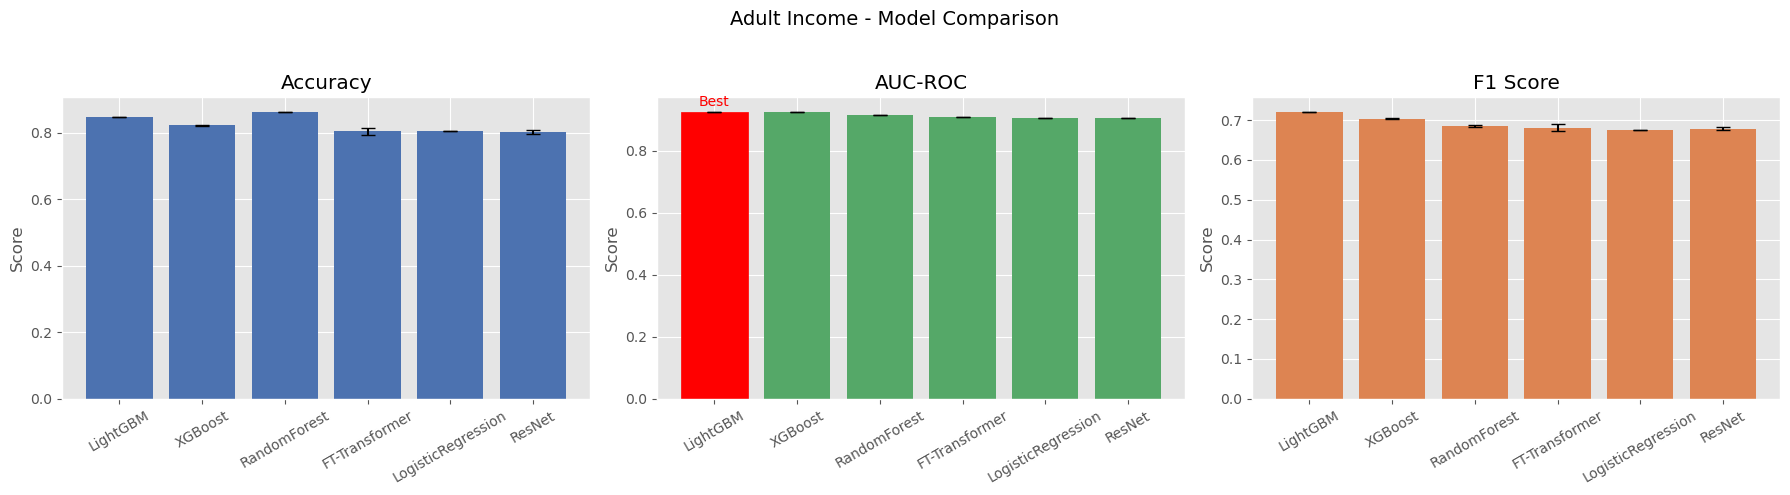

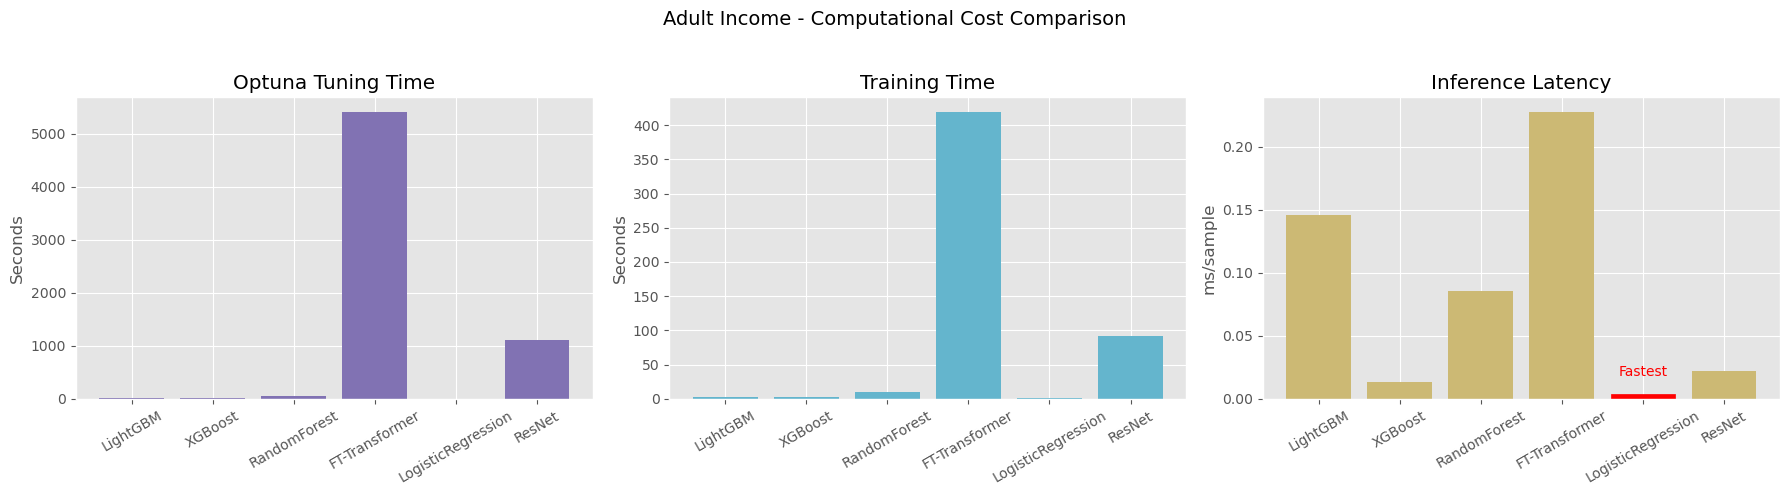

In [87]:
# Plot settings
methods = [
    "LightGBM", "XGBoost", "RandomForest",
    "FT-Transformer", "LogisticRegression", "ResNet"
]

plt.style.use("ggplot")

# Performance plot
methods_perf = [m for m in methods if m in summary.index]
summary_plot = summary.loc[methods_perf]

color_acc = "#4C72B0"
color_auc = "#55A868"
color_f1  = "#DD8452"

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy
axes[0].bar(
    summary_plot.index,
    summary_plot["acc_mean"],
    yerr=summary_plot["acc_std"],
    capsize=5,
    color=color_acc
)
axes[0].set_title("Accuracy")
axes[0].set_ylabel("Score")
axes[0].tick_params(axis="x", rotation=30)

# AUC
bars_auc = axes[1].bar(
    summary_plot.index,
    summary_plot["auc_mean"],
    yerr=summary_plot["auc_std"],
    capsize=5,
    color=color_auc
)
axes[1].set_title("AUC-ROC")
axes[1].set_ylabel("Score")
axes[1].tick_params(axis="x", rotation=30)

best_idx = summary_plot["auc_mean"].idxmax()
best_pos = summary_plot.index.get_loc(best_idx)
bars_auc[best_pos].set_color("red")

offset = 0.01 * summary_plot["auc_mean"].max()
axes[1].text(
    best_pos,
    summary_plot.loc[best_idx, "auc_mean"] + offset,
    "Best",
    ha="center",
    va="bottom",
    color="red",
    fontsize=10
)

# F1
axes[2].bar(
    summary_plot.index,
    summary_plot["f1_mean"],
    yerr=summary_plot["f1_std"],
    capsize=5,
    color=color_f1
)
axes[2].set_title("F1 Score")
axes[2].set_ylabel("Score")
axes[2].tick_params(axis="x", rotation=30)

fig.suptitle("Adult Income - Model Comparison", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Computational cost plot
methods_time = [m for m in methods if m in df_time_summary["method"].values]
df_time_plot = (
    df_time_summary.set_index("method")
    .loc[methods_time]
    .reset_index()
)

color_optuna = "#8172B3"
color_train = "#64B5CD"
color_latency = "#CCB974"

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Optuna tuning time
axes[0].bar(
    df_time_plot["method"],
    df_time_plot["optuna_time"],
    color=color_optuna
)
axes[0].set_title("Optuna Tuning Time")
axes[0].set_ylabel("Seconds")
axes[0].tick_params(axis="x", rotation=30)

# Training time
axes[1].bar(
    df_time_plot["method"],
    df_time_plot["train_time"],
    color=color_train
)
axes[1].set_title("Training Time")
axes[1].set_ylabel("Seconds")
axes[1].tick_params(axis="x", rotation=30)

# Inference latency
bars_latency = axes[2].bar(
    df_time_plot["method"],
    df_time_plot["Latency (ms/sample)"],
    color=color_latency
)
axes[2].set_title("Inference Latency")
axes[2].set_ylabel("ms/sample")
axes[2].tick_params(axis="x", rotation=30)

best_latency_idx = df_time_plot["Latency (ms/sample)"].idxmin()
best_latency_pos = df_time_plot.index.get_loc(best_latency_idx)
bars_latency[best_latency_pos].set_color("red")

offset = 0.05 * df_time_plot["Latency (ms/sample)"].max()
axes[2].text(
    best_latency_pos,
    df_time_plot.loc[best_latency_idx, "Latency (ms/sample)"] + offset,
    "Fastest",
    ha="center",
    va="bottom",
    color="red",
    fontsize=10
)

fig.suptitle("Adult Income - Computational Cost Comparison", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

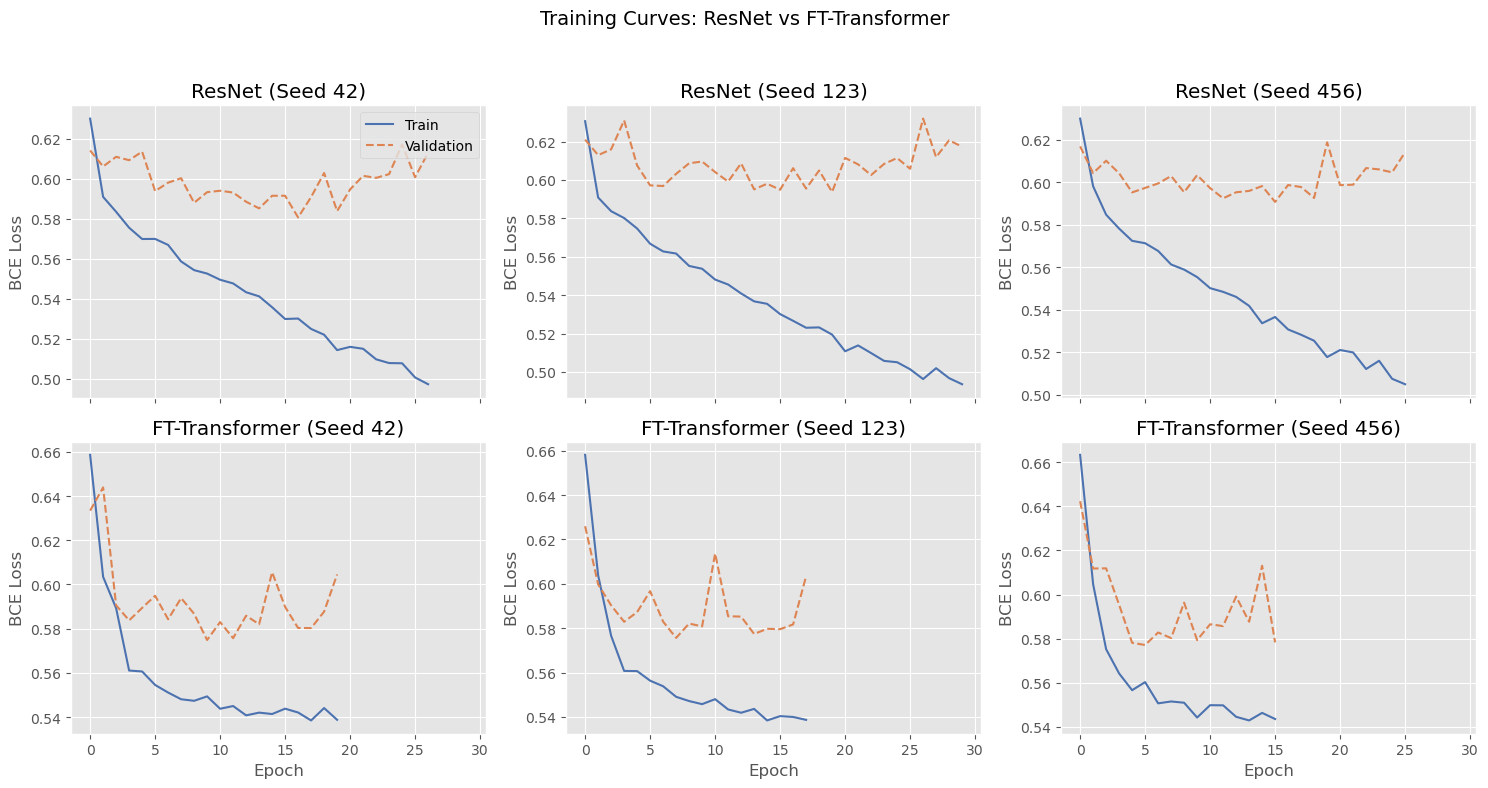

In [88]:
# Training Curves: ResNet vs FT-Transformer

n_seeds = len(SEEDS)

color_train = "#4C72B0"   # blue
color_val   = "#DD8452"   # orange

plt.style.use("ggplot")

fig, axes = plt.subplots(2, n_seeds, figsize=(5 * n_seeds, 8), sharex=True)

# Ensure axes shape is consistent
if n_seeds == 1:
    axes = axes.reshape(2, 1)

# ResNet (top row)
for i, seed in enumerate(SEEDS):
    ax = axes[0, i]

    if seed in resnet_train_curves:
        tr_l, va_l = resnet_train_curves[seed]

        ax.plot(tr_l, label="Train", color=color_train, linewidth=1.5)
        ax.plot(va_l, label="Validation", color=color_val, linestyle="--", linewidth=1.5)

    ax.set_title(f"ResNet (Seed {seed})")
    ax.set_ylabel("BCE Loss")

# FT-Transformer (bottom row)
for i, seed in enumerate(SEEDS):
    ax = axes[1, i]

    if seed in ft_train_curves:
        tr_l, va_l = ft_train_curves[seed]

        ax.plot(tr_l, label="Train", color=color_train, linewidth=1.5)
        ax.plot(va_l, label="Validation", color=color_val, linestyle="--", linewidth=1.5)

    ax.set_title(f"FT-Transformer (Seed {seed})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("BCE Loss")

# Single legend (top-left plot)
axes[0, 0].legend(loc="upper right")

# Final layout
fig.suptitle("Training Curves: ResNet vs FT-Transformer", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

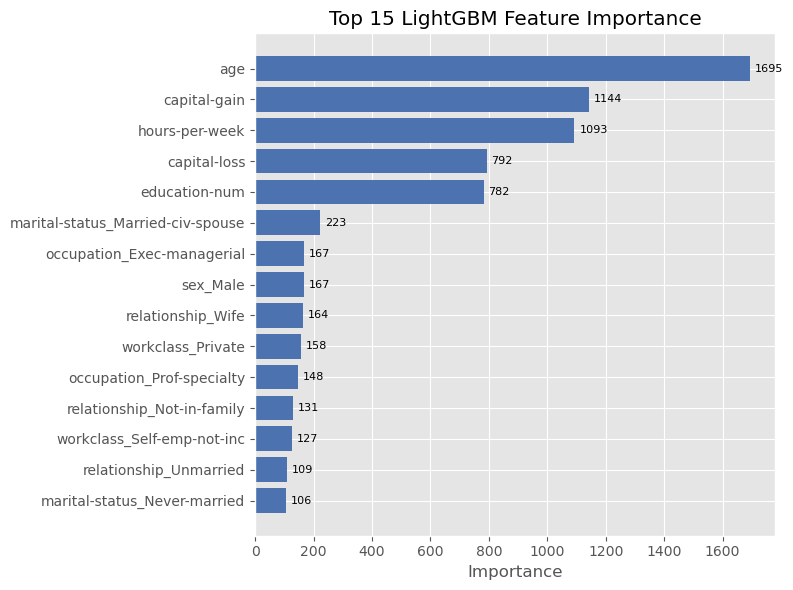

In [89]:
# Top 15 LightGBM Feature Importance

if "lgb_model_best" in globals() and lgb_model_best is not None:

    # Build feature importance DataFrame
    fi_df = pd.DataFrame({
        "feature": X_train_c.columns,
        "importance": lgb_model_best.feature_importances_,
    })

    # Top 15 features
    fi_df = (
        fi_df.sort_values("importance", ascending=False)
        .head(15)
        .sort_values("importance", ascending=True)
    )

    color_bar = "#4C72B0"

    plt.style.use("ggplot")
    fig, ax = plt.subplots(figsize=(8, 6))

    bars = ax.barh(fi_df["feature"], fi_df["importance"], color=color_bar)

    # Add value labels (with slight offset)
    max_val = fi_df["importance"].max()
    offset = 0.01 * max_val

    for i, v in enumerate(fi_df["importance"]):
        ax.text(v + offset, i, f"{v:.0f}", va="center", fontsize=8)

    ax.set_title("Top 15 LightGBM Feature Importance")
    ax.set_xlabel("Importance")
    ax.set_ylabel("")

    plt.tight_layout()
    plt.show()

In [90]:
# Get best LightGBM seed based on AUC
lgb_results = [r for r in all_results if r["method"] == "LightGBM"]

best_seed = max(lgb_results, key=lambda x: x["auc"])["seed"]

print("Best LightGBM seed based on AUC:", best_seed)

# Re-train best model
set_seed(best_seed)

lgb_model_best = lgb.LGBMClassifier(
    **best_lgb,
    objective="binary",
    metric="auc",
    random_state=best_seed,
    verbosity=-1,
    n_jobs=-1
)

lgb_model_best.fit(X_train_c, y_train_np)

Best LightGBM seed based on AUC: 123


LGBMClassifier(colsample_bytree=0.8144754354791038,
               learning_rate=0.02847748683027988, metric='auc',
               min_child_samples=32, n_estimators=478, n_jobs=-1, num_leaves=20,
               objective='binary', random_state=123,
               reg_alpha=1.368174031940222e-08, reg_lambda=0.003327054963436224,
               scale_pos_weight=2.2968016075731468, subsample=0.751180619986081,
               verbosity=-1)

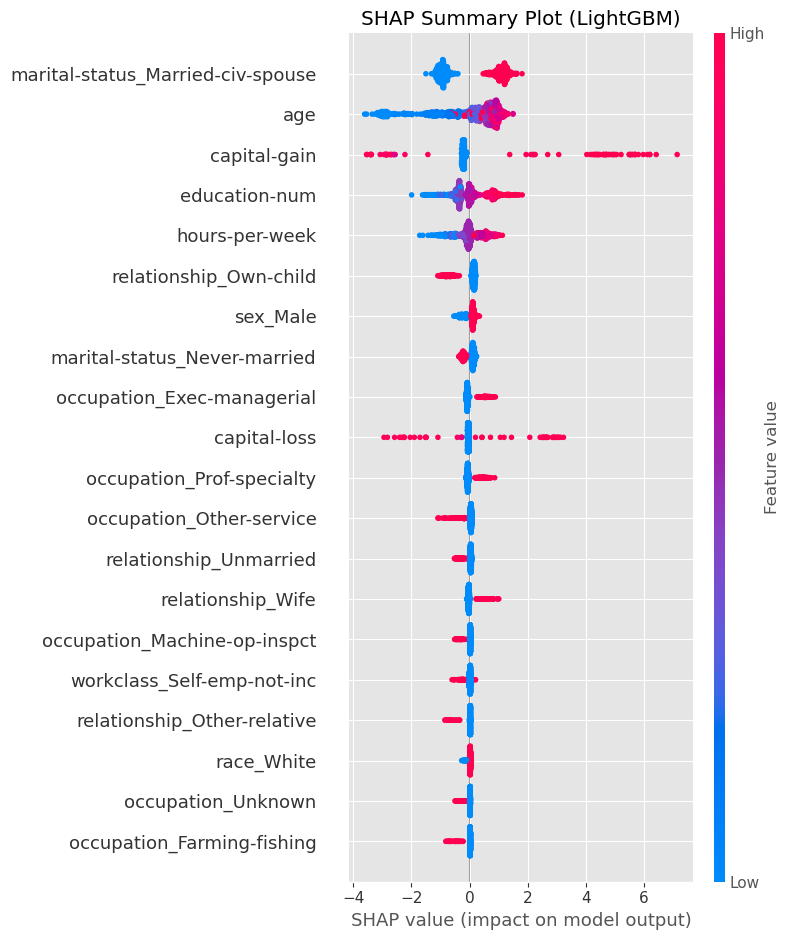

In [91]:
# SHAP Summary Plot (LightGBM)

import shap

# Sample for speed
X_shap = X_test_c.sample(min(1000, len(X_test_c)), random_state=42)

# Explainer
explainer = shap.TreeExplainer(lgb_model_best)

# SHAP values
shap_values = explainer.shap_values(X_shap)

# Handle different SHAP outputs
if isinstance(shap_values, list):
    # Older SHAP binary-classification output
    shap_to_plot = shap_values[1]
elif hasattr(shap_values, "values"):
    # Newer Explanation object
    shap_to_plot = shap_values.values
else:
    shap_to_plot = shap_values

# Plot
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_to_plot, X_shap, show=False)

plt.title("SHAP Summary Plot (LightGBM)")
plt.tight_layout()
plt.show()

## Analysis & Conclusions

### Summary
We compared six methods on the UCI Adult Income binary classification task.

- **LightGBM** and **XGBoost** typically achieve top AUC-ROC on this dataset
  thanks to their ability to handle mixed numerical/categorical features.
- **FT-Transformer** leverages embeddings for categorical features, which can
  yield competitive AUC with sufficient training.
- **Logistic Regression** provides a fast and interpretable baseline.
- **ResNet** and **Random Forest** round out the comparison.

### Observations
- The dataset is moderately imbalanced (~24% positive); AUC-ROC is the most
  reliable metric here.
- OrdinalEncoding + StandardScaling is a straightforward preprocessing pipeline
  that works across all methods.
- 3-seed evaluation reveals model stability under random initialization.

### Next Steps
- One-hot encoding for tree methods vs. ordinal for neural methods. /
- Class-weight adjustment to improve F1 for the minority class.
- SHAP explanations for the best-performing model. /
